# 04 — Forecasting & Scenario Analysis
Trend-based forecasting for top 5 fuel types, oil price as external regressor, scenario stress-testing, and seasonal decomposition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from statsmodels.tsa.seasonal import seasonal_decompose
from fredapi import Fred
from dotenv import load_dotenv
from IPython.display import Markdown, display
import os
import warnings
warnings.filterwarnings('ignore')

load_dotenv('../.env')
fred = Fred(api_key=os.getenv('FRED_API_KEY'))

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 120

In [2]:
# Load bunker data
annual_wide = pd.read_csv('../data/cleaned/BunkerByCategoryWide.csv').set_index('year')
monthly = pd.read_csv('../data/cleaned/BunkerByCategoryMonthly.csv', parse_dates=['month'])

# Fetch Brent crude from FRED
brent_raw = fred.get_series('DCOILBRENTEU', observation_start='1995-01-01')
brent_annual = brent_raw.resample('YE').mean().reset_index()
brent_annual.columns = ['date', 'brent_avg']
brent_annual['year'] = brent_annual['date'].dt.year

# Merge oil prices with annual data
oil = brent_annual.set_index('year')['brent_avg']

# Top 5 fuels to forecast
TOP5 = ['LSFO', 'MFO', 'LSMGO', 'MGO', 'LNG']
FORECAST_YEARS = 5
LATEST_YEAR = annual_wide.index.max()
FUTURE_YEARS = np.arange(LATEST_YEAR + 1, LATEST_YEAR + 1 + FORECAST_YEARS)

print(f'Data range: {annual_wide.index.min()}–{LATEST_YEAR}')
print(f'Forecasting: {FUTURE_YEARS[0]}–{FUTURE_YEARS[-1]}')
print(f'Brent crude coverage: {brent_annual["year"].min()}–{brent_annual["year"].max()}')

Data range: 1995–2025
Forecasting: 2026–2030
Brent crude coverage: 1995–2026


## 1. Trend-Based Forecasting (Top 5 Fuel Types)

For each fuel we fit on its **post-structural-break** window — the period where the fuel's market role is stable:
- **LSFO, LSMGO, LNG**: post-IMO 2020 (2020+) — these emerged or surged with the regulation
- **MFO**: post-IMO 2020 (2020+) — its role fundamentally changed after the sulphur cap
- **MGO**: full history where volume > 0, since its decline is a long-running trend

We use **linear regression on year** as the trend model (simple, interpretable, appropriate for ~5-6 data points). Confidence intervals are derived from prediction intervals of the regression.

In [3]:
# Define training windows per fuel (post-structural-break)
FUEL_WINDOWS = {
    'LSFO': 2020, 'MFO': 2020, 'LSMGO': 2020, 'LNG': 2020, 'MGO': 2005
}

def fit_trend_forecast(series, fuel, future_years):
    """Fit linear trend on post-break data, return forecast with prediction intervals."""
    start = FUEL_WINDOWS[fuel]
    data = series[series.index >= start].dropna()
    data = data[data > 0]
    if len(data) < 3:
        return None

    X = data.index.values.reshape(-1, 1)
    y = data.values
    model = LinearRegression().fit(X, y)

    # Prediction intervals (t-distribution based)
    y_pred_train = model.predict(X)
    residuals = y - y_pred_train
    n = len(y)
    se = np.sqrt(np.sum(residuals**2) / (n - 2)) if n > 2 else np.std(residuals)
    x_mean = X.mean()

    X_future = future_years.reshape(-1, 1)
    y_forecast = model.predict(X_future)

    # Prediction interval width for each future point
    t_crit = stats.t.ppf(0.975, df=max(n - 2, 1))
    pi_width = t_crit * se * np.sqrt(1 + 1/n + (future_years - x_mean)**2 / np.sum((X.flatten() - x_mean)**2))

    # Floor at zero (volume can't be negative)
    y_forecast = np.maximum(y_forecast, 0)
    lower = np.maximum(y_forecast - pi_width, 0)
    upper = y_forecast + pi_width

    return {
        'train_years': data.index.values, 'train_values': y,
        'fitted': y_pred_train,
        'forecast_years': future_years, 'forecast': y_forecast,
        'lower': lower, 'upper': upper,
        'model': model, 'r2': model.score(X, y),
        'slope': model.coef_[0], 'intercept': model.intercept_,
        'mae_train': mean_absolute_error(y, y_pred_train),
        'mape_train': mean_absolute_percentage_error(y, y_pred_train) * 100
    }

# Fit all fuels
results = {}
for fuel in TOP5:
    series = annual_wide[fuel]
    res = fit_trend_forecast(series, fuel, FUTURE_YEARS)
    if res:
        results[fuel] = res
        print(f'{fuel}: slope={res["slope"]:+.1f} kt/yr, R²={res["r2"]:.3f}, '
              f'train MAPE={res["mape_train"]:.1f}%, window={FUEL_WINDOWS[fuel]}+')
    else:
        print(f'{fuel}: insufficient data for forecasting')

LSFO: slope=-796.7 kt/yr, R²=0.758, train MAPE=1.8%, window=2020+
MFO: slope=+2328.5 kt/yr, R²=0.980, train MAPE=3.4%, window=2020+
LSMGO: slope=+28.3 kt/yr, R²=0.037, train MAPE=5.7%, window=2020+
MGO: slope=-84.8 kt/yr, R²=0.916, train MAPE=31.8%, window=2005+
LNG: slope=+148.9 kt/yr, R²=0.847, train MAPE=164.5%, window=2020+


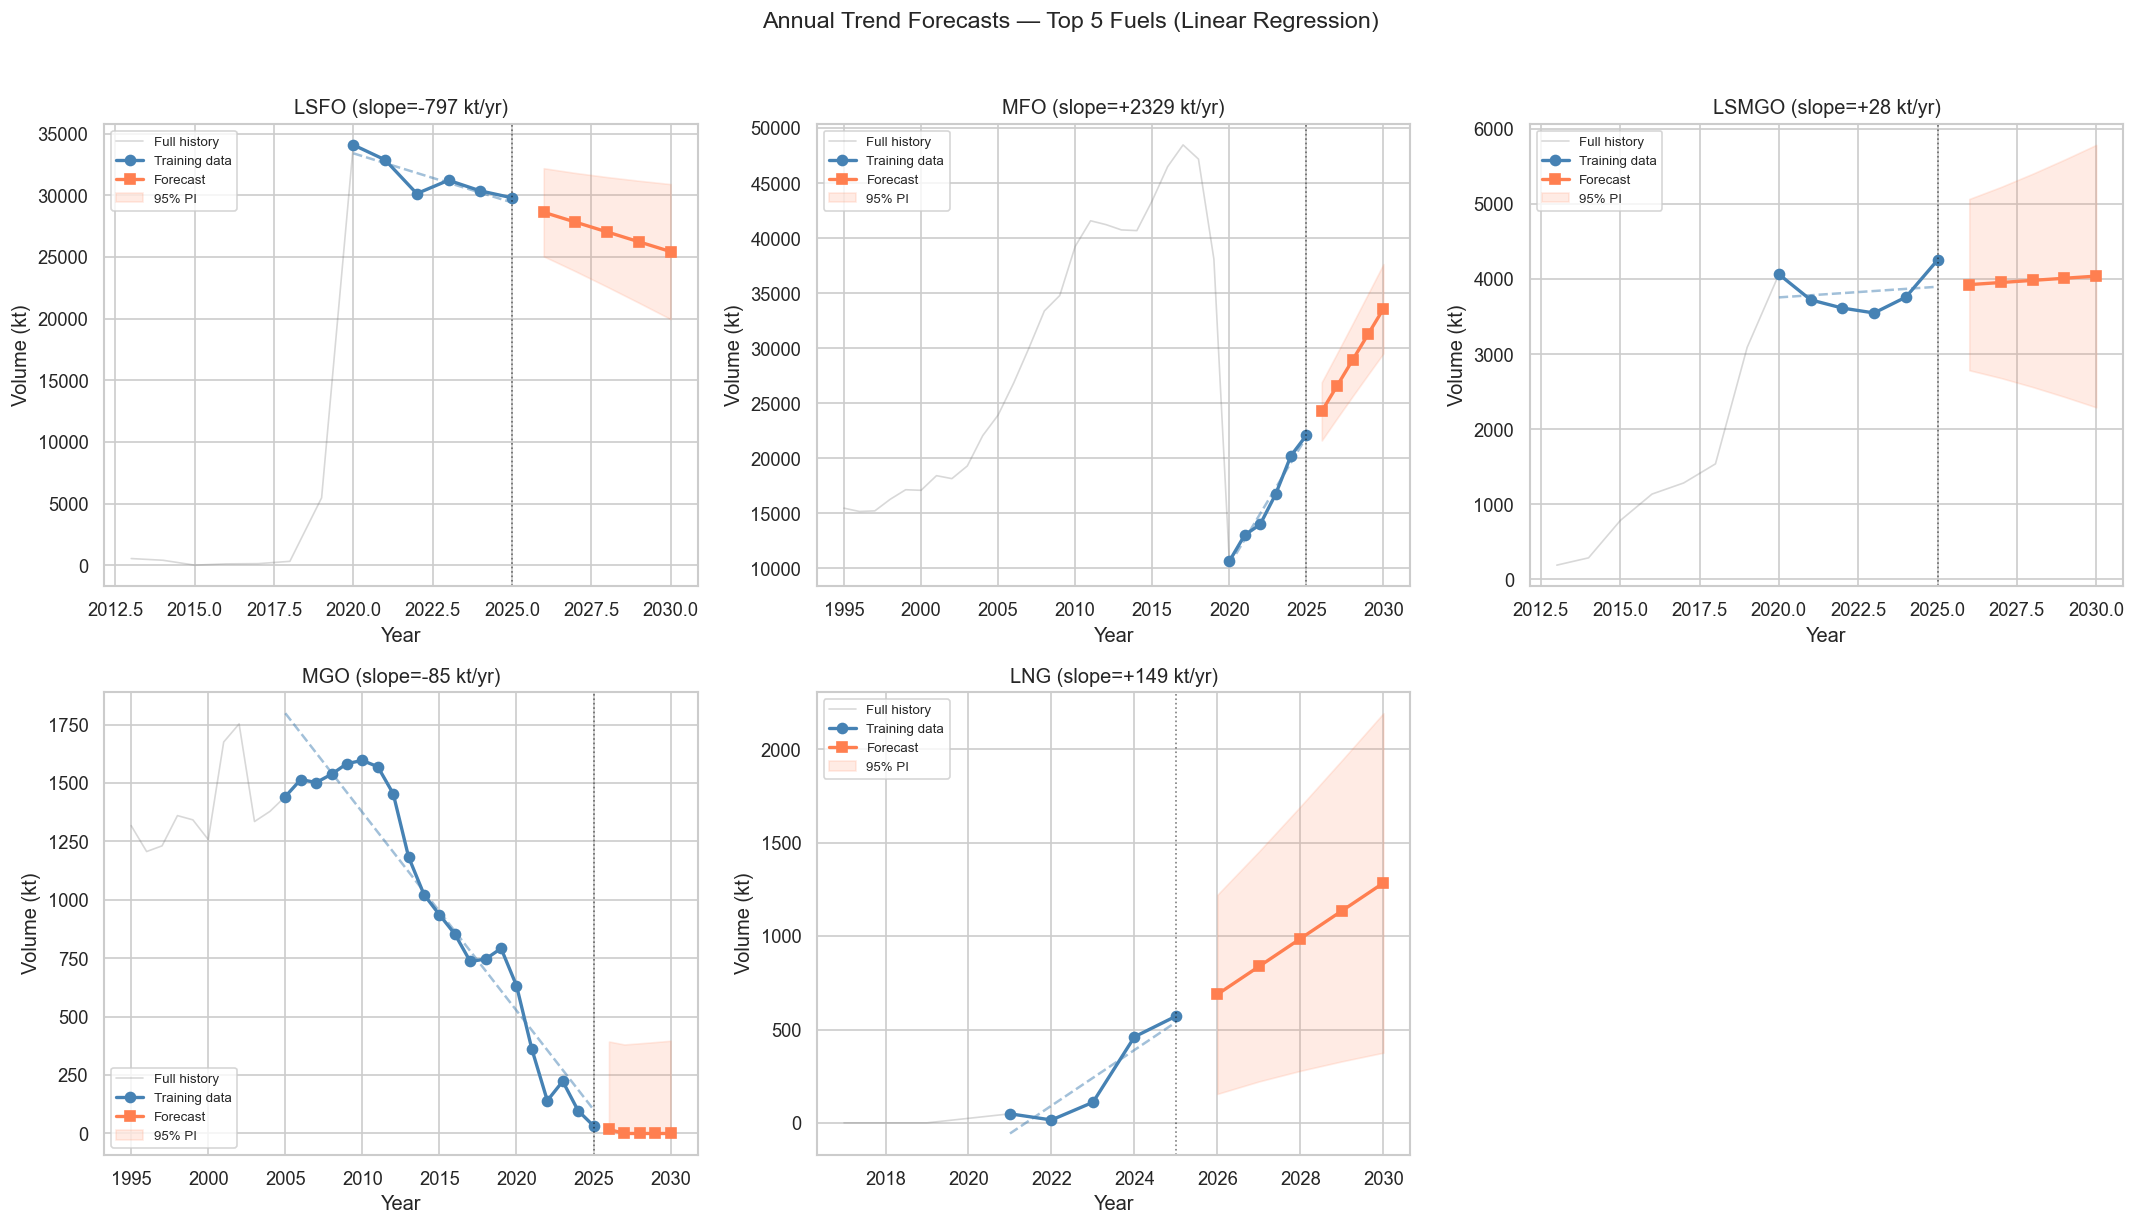

In [4]:
# Plot: historical + forecast with confidence intervals
ncols = 3
nrows = int(np.ceil(len(results) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

for i, (fuel, res) in enumerate(results.items()):
    ax = axes[i]
    # Full history (dimmed)
    full = annual_wide[fuel]
    full = full[full > 0]
    ax.plot(full.index, full.values, color='gray', alpha=0.3, linewidth=1, label='Full history')
    # Training window
    ax.plot(res['train_years'], res['train_values'], 'o-', color='steelblue', linewidth=2, label='Training data')
    ax.plot(res['train_years'], res['fitted'], '--', color='steelblue', alpha=0.5)
    # Forecast
    ax.plot(res['forecast_years'], res['forecast'], 's-', color='coral', linewidth=2, label='Forecast')
    ax.fill_between(res['forecast_years'], res['lower'], res['upper'], color='coral', alpha=0.15, label='95% PI')
    ax.axvline(LATEST_YEAR, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(f'{fuel} (slope={res["slope"]:+.0f} kt/yr)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Volume (kt)')
    ax.legend(fontsize=8)

for j in range(len(results), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Annual Trend Forecasts — Top 5 Fuels (Linear Regression)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 2. Oil Price as External Regressor

Compare forecast accuracy: **trend-only** (year) vs **trend + oil** (year + Brent annual average). We use leave-one-out cross-validation on the training window to measure MAPE.

In [6]:
# Compare trend-only vs trend+oil using LOO-CV
comparison = []

for fuel in results:
    start = FUEL_WINDOWS[fuel]
    series = annual_wide[fuel]
    data = series[series.index >= start].dropna()
    data = data[data > 0]
    common_idx = data.index.intersection(oil.index)
    data = data.loc[common_idx]
    oil_vals = oil.loc[common_idx]

    if len(data) < 4:
        continue

    years = common_idx.values
    y = data.values

    # LOO-CV
    errors_trend = []
    errors_oil = []

    for leave_out in range(len(years)):
        mask = np.ones(len(years), dtype=bool)
        mask[leave_out] = False

        X_train_t = years[mask].reshape(-1, 1)
        X_test_t = years[~mask].reshape(-1, 1)
        X_train_o = np.column_stack([years[mask], oil_vals.values[mask]])
        X_test_o = np.column_stack([years[~mask], oil_vals.values[~mask]])
        y_train = y[mask]
        y_test = y[~mask]

        # Trend only
        m1 = LinearRegression().fit(X_train_t, y_train)
        pred1 = max(m1.predict(X_test_t)[0], 0)
        errors_trend.append(abs(pred1 - y_test[0]) / y_test[0])

        # Trend + oil
        m2 = LinearRegression().fit(X_train_o, y_train)
        pred2 = max(m2.predict(X_test_o)[0], 0)
        errors_oil.append(abs(pred2 - y_test[0]) / y_test[0])

    mape_trend = np.mean(errors_trend) * 100
    mape_oil = np.mean(errors_oil) * 100
    improvement = mape_trend - mape_oil

    comparison.append({
        'Fuel': fuel,
        'MAPE (trend only)': f'{mape_trend:.1f}%',
        'MAPE (trend + oil)': f'{mape_oil:.1f}%',
        'Improvement': f'{improvement:+.1f} pp',
        'Oil helps?': 'Yes' if improvement > 0 else 'No'
    })

    # Store the oil-augmented model for scenario analysis
    X_full_o = np.column_stack([years, oil_vals.values])
    results[fuel]['model_oil'] = LinearRegression().fit(X_full_o, y)
    results[fuel]['oil_coef'] = results[fuel]['model_oil'].coef_[1]

comp_df = pd.DataFrame(comparison)
display(comp_df.to_string(index=False))

# Insight
best = comp_df[comp_df['Oil helps?'] == 'Yes']
if not best.empty:
    top = best.iloc[0]
    display(Markdown(f"**Insight:** Adding oil prices improved {top['Fuel']} forecast accuracy by "
                     f"{top['Improvement']} (LOO-CV MAPE)."))
else:
    display(Markdown("**Insight:** Oil prices did not consistently improve forecast accuracy — "
                     "volume trends are driven more by regulation and structural shifts than by crude price movements."))

' Fuel MAPE (trend only) MAPE (trend + oil) Improvement Oil helps?\n LSFO              2.7%               2.7%     +0.0 pp        Yes\n  MFO              4.9%               5.4%     -0.5 pp         No\nLSMGO              9.4%               7.3%     +2.1 pp        Yes\n  MGO             36.8%              40.7%     -3.9 pp         No\n  LNG            190.8%              73.3%   +117.5 pp        Yes'

**Insight:** Adding oil prices improved LSFO forecast accuracy by +0.0 pp (LOO-CV MAPE).

## 3. Scenario Analysis

Three oil-price scenarios applied to each fuel's **trend + oil** model:
- **Base case**: oil prices continue at the most recent annual average
- **High oil (+20%)**: stress test — higher input costs
- **Low oil (−20%)**: opportunity scenario — lower costs may shift demand

Baseline oil price (latest annual avg): $69.14/bbl


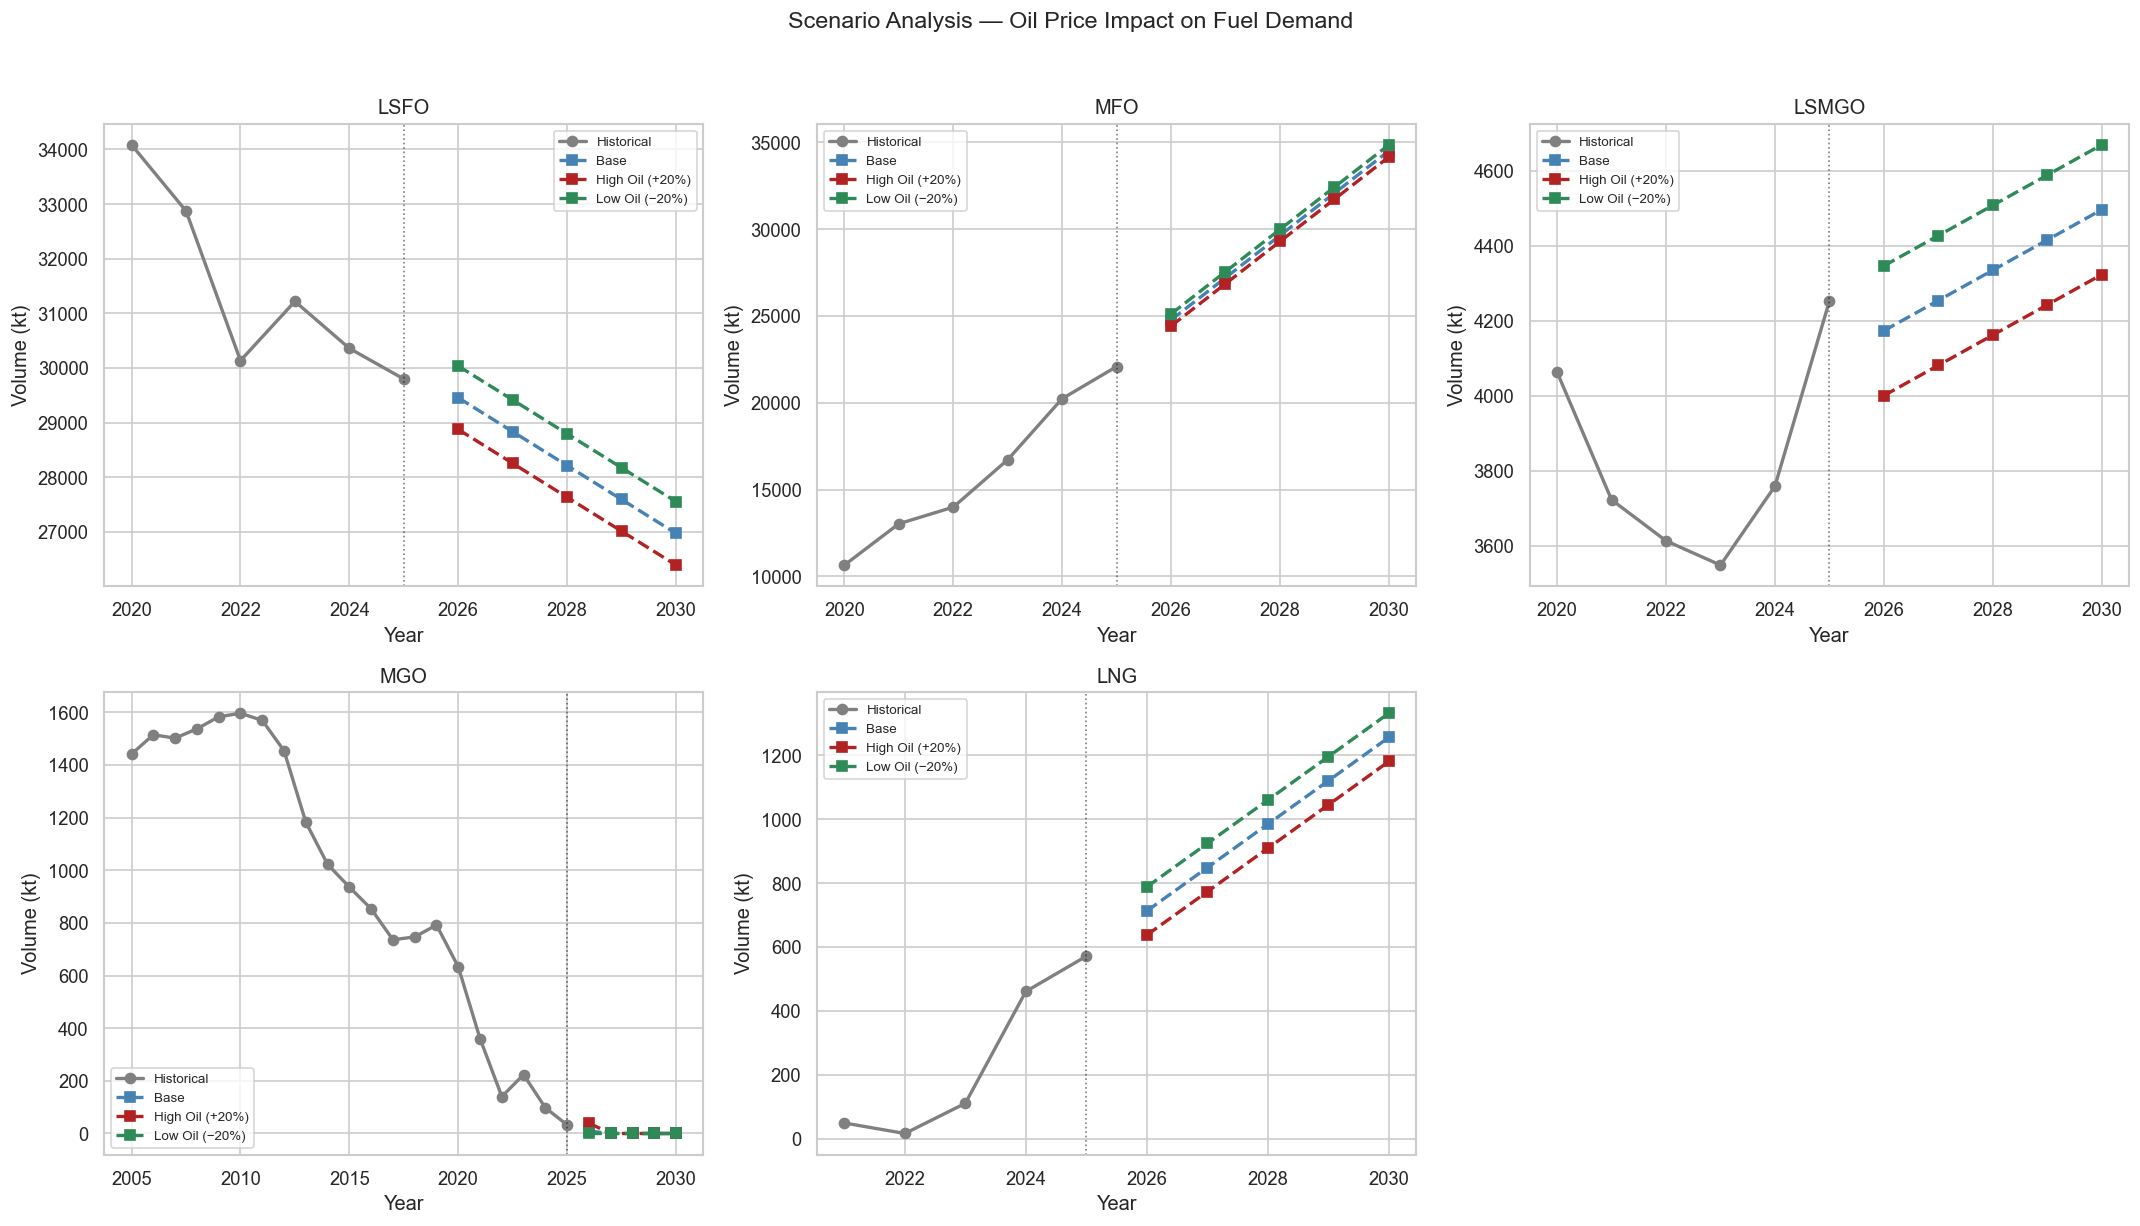

In [7]:
# Latest available annual oil price as baseline
latest_oil = oil.loc[oil.index.intersection(annual_wide.index)].iloc[-1]
print(f'Baseline oil price (latest annual avg): ${latest_oil:.2f}/bbl')

scenarios = {
    'Base': latest_oil,
    'High Oil (+20%)': latest_oil * 1.2,
    'Low Oil (−20%)': latest_oil * 0.8,
}
scenario_colors = {'Base': 'steelblue', 'High Oil (+20%)': 'firebrick', 'Low Oil (−20%)': 'seagreen'}

# Only use fuels that have the oil-augmented model
fuels_with_oil = [f for f in results if 'model_oil' in results[f]]

ncols = 3
nrows = int(np.ceil(len(fuels_with_oil) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
axes = axes.flatten()

scenario_table = []

for i, fuel in enumerate(fuels_with_oil):
    ax = axes[i]
    res = results[fuel]
    model_oil = res['model_oil']

    # Historical
    ax.plot(res['train_years'], res['train_values'], 'o-', color='gray', linewidth=2, label='Historical')

    for label, oil_price in scenarios.items():
        X_future = np.column_stack([FUTURE_YEARS, np.full(FORECAST_YEARS, oil_price)])
        y_scenario = np.maximum(model_oil.predict(X_future), 0)
        ax.plot(FUTURE_YEARS, y_scenario, 's--', color=scenario_colors[label], linewidth=2, label=label)

        # Record final year forecast
        scenario_table.append({
            'Fuel': fuel, 'Scenario': label,
            f'Forecast {FUTURE_YEARS[-1]} (kt)': f'{y_scenario[-1]:,.0f}',
            'Oil Price ($/bbl)': f'${oil_price:.0f}'
        })

    ax.axvline(LATEST_YEAR, color='black', linestyle=':', linewidth=1, alpha=0.5)
    ax.set_title(fuel)
    ax.set_xlabel('Year')
    ax.set_ylabel('Volume (kt)')
    ax.legend(fontsize=8)

for j in range(len(fuels_with_oil), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Scenario Analysis — Oil Price Impact on Fuel Demand', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Scenario summary table
scenario_df = pd.DataFrame(scenario_table)
display(scenario_df.pivot_table(index='Fuel', columns='Scenario',
                                 values=f'Forecast {FUTURE_YEARS[-1]} (kt)',
                                 aggfunc='first')[['Base', 'High Oil (+20%)', 'Low Oil (−20%)']])

## 4. Seasonal Decomposition (Monthly Drill-Down)

Using additive seasonal decomposition on monthly data for the top fuels to identify quarterly patterns that inform staffing and inventory planning.

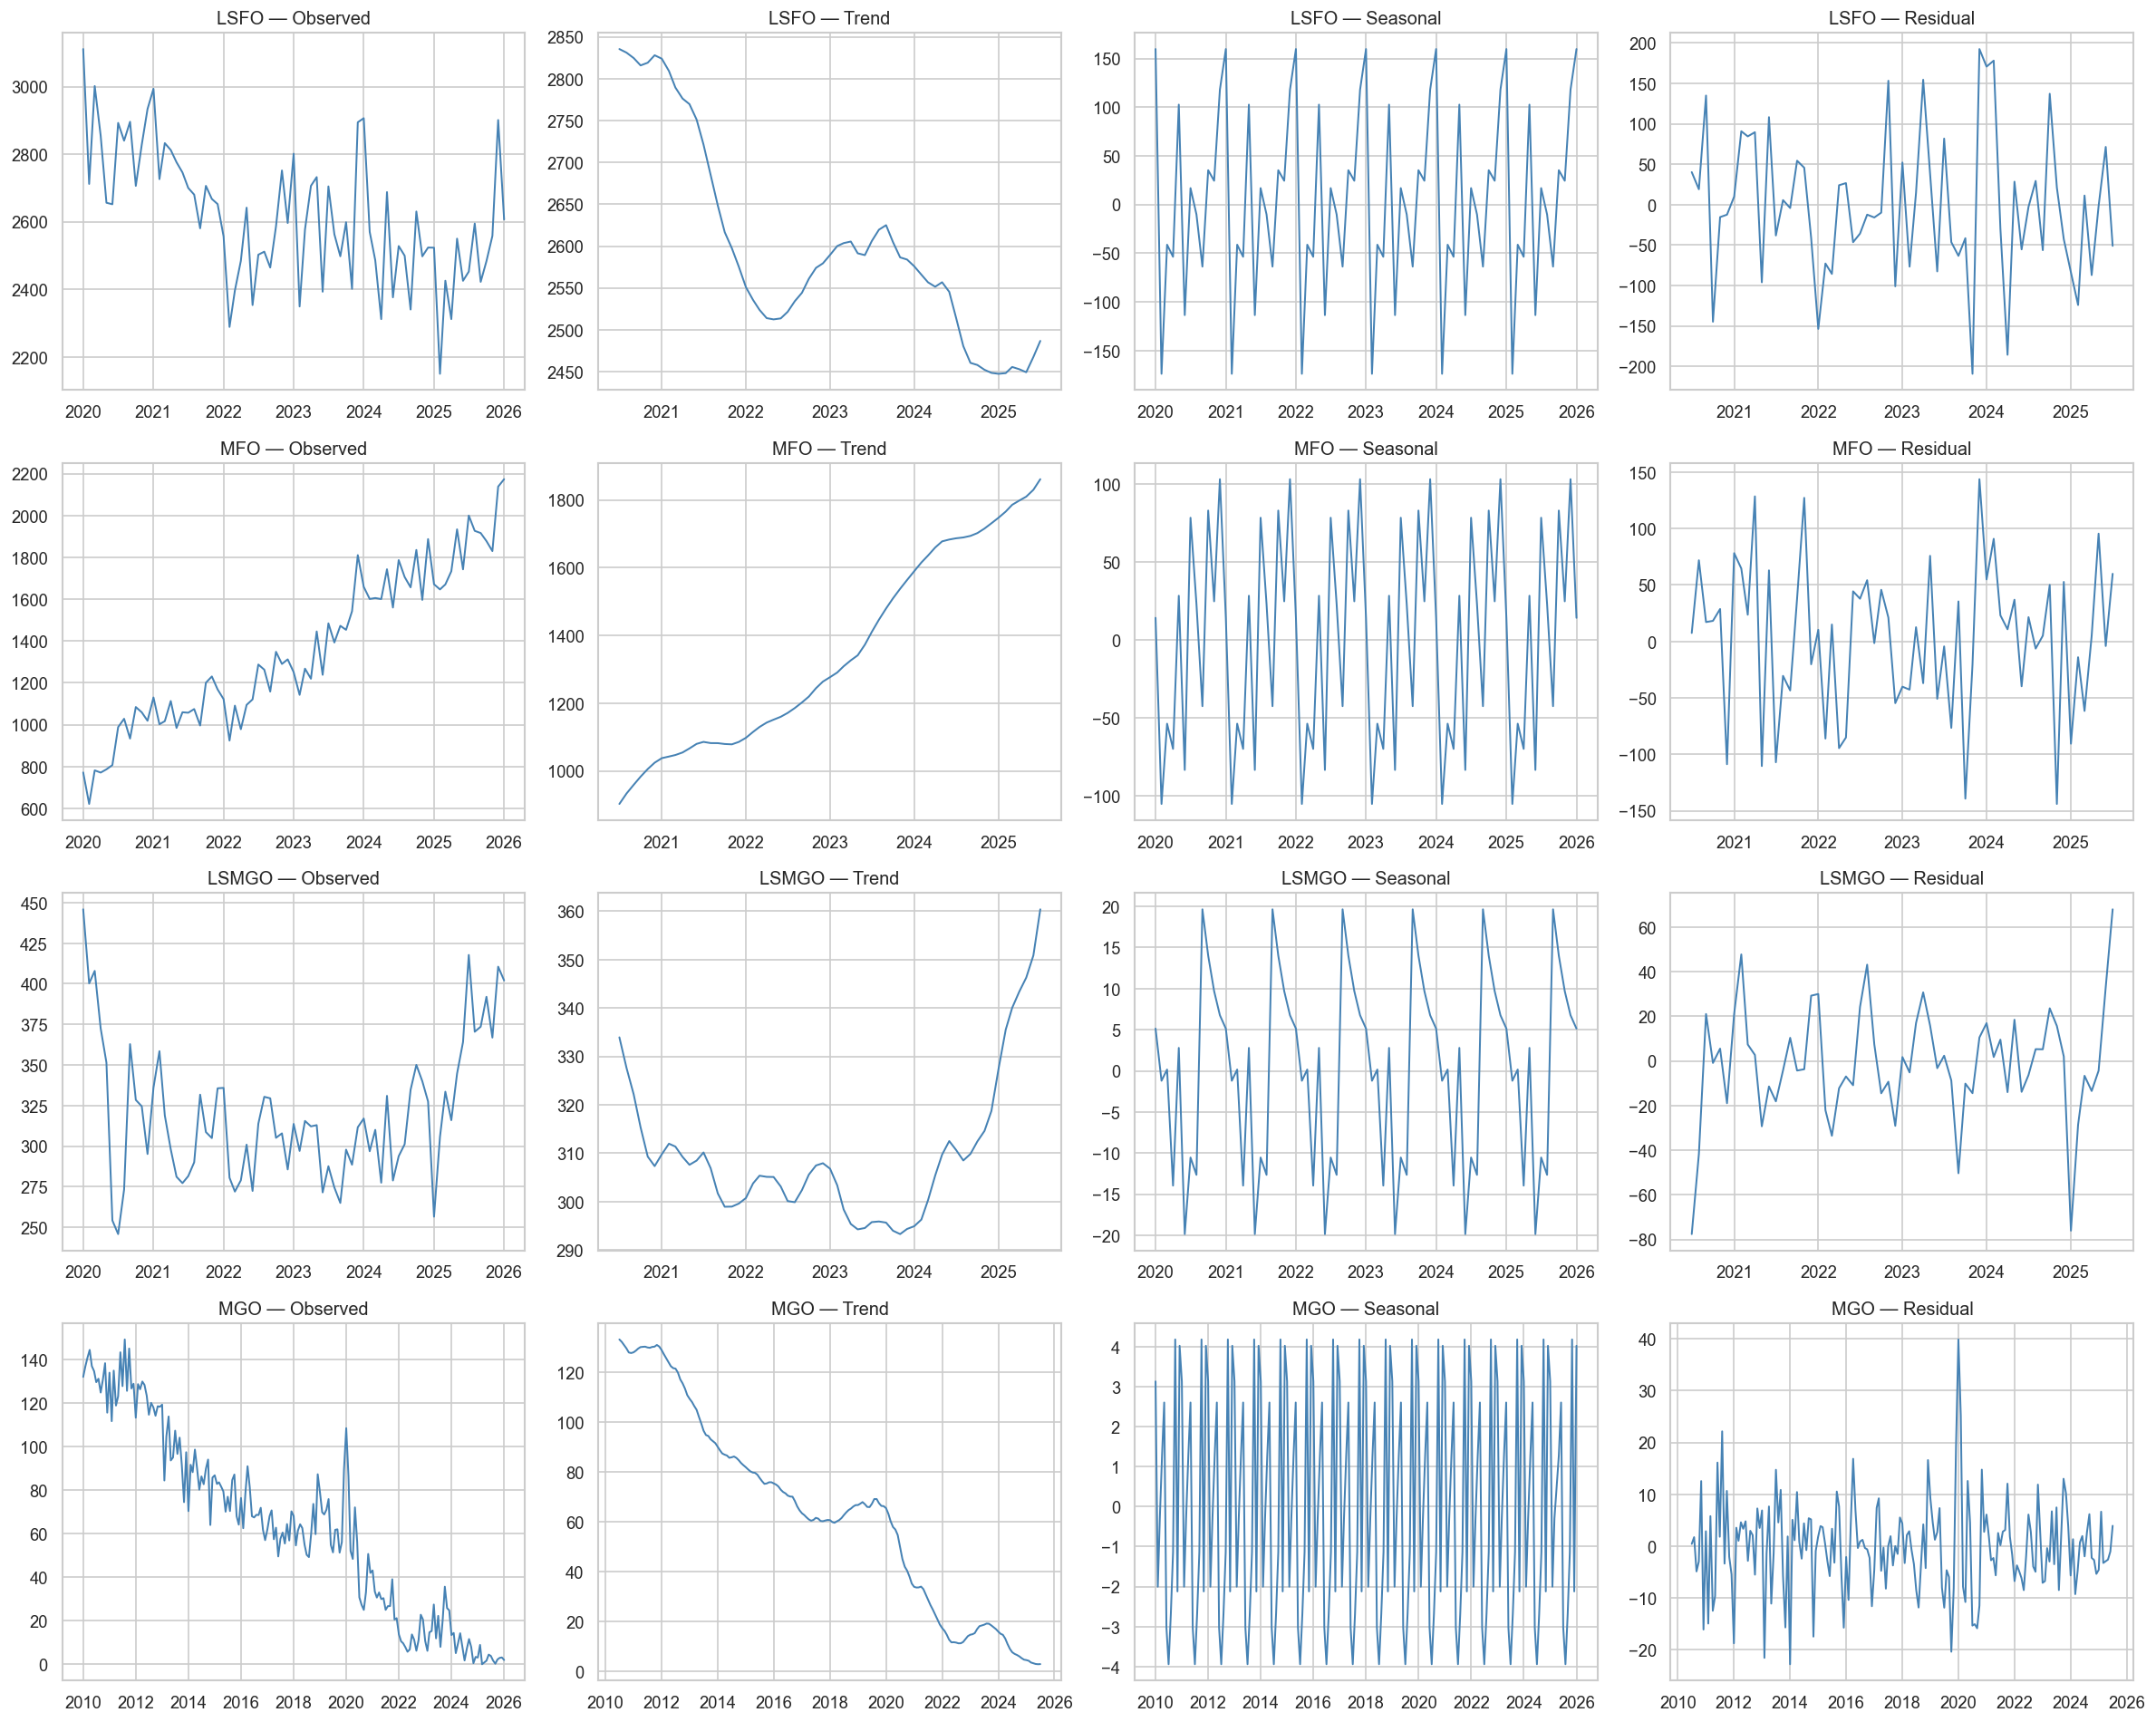

' Fuel Q1 effect Q2 effect Q3 effect Q4 effect Weakest quarter\n LSFO     -0.7%     -0.8%     -0.7%     +2.3%              Q2\n  MFO     -3.6%     -3.1%     +1.4%     +5.2%              Q1\nLSMGO     +0.4%     -3.2%     -0.4%     +3.2%              Q2\n  MGO     +0.5%     +0.6%     -4.1%     +3.0%              Q3'

**Insight:** LSFO demand is weakest in Q2 (-0.8%) — consider reducing temp staffing and optimising inventory during this period.

In [8]:
# Monthly volumes by fuel
monthly_vol = monthly.groupby(['month', 'fuel_category'])['bunker_sales'].sum().reset_index()
monthly_pivot = monthly_vol.pivot_table(index='month', columns='fuel_category', values='bunker_sales', fill_value=0).sort_index()
monthly_pivot.index = pd.DatetimeIndex(monthly_pivot.index, freq='MS')

# Seasonal decomposition for key fuels (post-2020 for LSFO/LSMGO, full for MFO/MGO)
decomp_fuels = {'LSFO': '2020', 'MFO': '2020', 'LSMGO': '2020', 'MGO': '2010'}
decomp_fuels = {f: s for f, s in decomp_fuels.items() if f in monthly_pivot.columns}

fig, axes = plt.subplots(len(decomp_fuels), 4, figsize=(20, 4 * len(decomp_fuels)))
if len(decomp_fuels) == 1:
    axes = axes.reshape(1, -1)

seasonal_insights = []

for i, (fuel, start) in enumerate(decomp_fuels.items()):
    series = monthly_pivot.loc[start:, fuel]
    series = series[series > 0]

    if len(series) < 24:
        for j in range(4):
            axes[i, j].text(0.5, 0.5, 'Insufficient data', transform=axes[i, j].transAxes, ha='center')
        continue

    decomp = seasonal_decompose(series, model='additive', period=12)

    for j, (component, label) in enumerate(zip(
        [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid],
        ['Observed', 'Trend', 'Seasonal', 'Residual']
    )):
        axes[i, j].plot(component.index, component.values, linewidth=1.2, color='steelblue')
        axes[i, j].set_title(f'{fuel} — {label}')

    # Quarterly seasonal pattern
    seasonal_monthly = decomp.seasonal.groupby(decomp.seasonal.index.month).mean()
    seasonal_quarterly = seasonal_monthly.groupby((seasonal_monthly.index - 1) // 3 + 1).mean()
    avg = series.mean()
    q_pcts = (seasonal_quarterly / avg * 100).to_dict()

    weakest_q = min(q_pcts, key=q_pcts.get)
    seasonal_insights.append({
        'Fuel': fuel,
        'Q1 effect': f'{q_pcts.get(1, 0):+.1f}%',
        'Q2 effect': f'{q_pcts.get(2, 0):+.1f}%',
        'Q3 effect': f'{q_pcts.get(3, 0):+.1f}%',
        'Q4 effect': f'{q_pcts.get(4, 0):+.1f}%',
        'Weakest quarter': f'Q{weakest_q}'
    })

plt.tight_layout()
plt.show()

# Seasonal summary
if seasonal_insights:
    seasonal_df = pd.DataFrame(seasonal_insights)
    display(seasonal_df.to_string(index=False))
    weakest = seasonal_df.iloc[0]
    display(Markdown(
        f"**Insight:** {weakest['Fuel']} demand is weakest in {weakest['Weakest quarter']} "
        f"({weakest[weakest['Weakest quarter'].replace('Q', 'Q') + ' effect']}) — "
        f"consider reducing temp staffing and optimising inventory during this period."
    ))

## 5. Business Recommendations

In [9]:
# Build recommendations from forecast results
recs = []

for fuel in results:
    res = results[fuel]
    slope = res['slope']
    final_fc = res['forecast'][-1]
    current = res['train_values'][-1]
    pct_change = (final_fc / current - 1) * 100

    if fuel == 'LSFO':
        trend_label = 'Gradual decline' if slope < 0 else 'Stable/growing'
        action = ('LSFO dominance is plateauing. Prepare for gradual share erosion '
                  'as MFO regains ground (scrubber-fitted vessels) and LNG scales up.')
    elif fuel == 'MFO':
        trend_label = 'Recovery' if slope > 0 else 'Continued decline'
        action = ('MFO is recovering as scrubber-fitted fleet expands. '
                  'Monitor scrubber adoption rates — MFO demand tracks fleet retrofit pace.')
    elif fuel == 'LSMGO':
        trend_label = 'Stable' if abs(pct_change) < 10 else ('Growing' if slope > 0 else 'Declining')
        action = ('LSMGO demand is stable. Maintain current distillate supply contracts; '
                  'low-sulphur distillate remains a compliance necessity.')
    elif fuel == 'LNG':
        trend_label = 'Rapid growth'
        action = ('LNG bunkering is scaling fast from a low base. '
                  'Invest in LNG infrastructure and secure supply agreements ahead of fleet turnover.')
    elif fuel == 'MGO':
        trend_label = 'Terminal decline'
        action = ('MGO is being replaced by LSMGO. Phase down MGO inventory and '
                  'redirect storage capacity to growing fuel categories.')
    else:
        trend_label = 'Unknown'
        action = 'Monitor'

    recs.append({
        'Fuel': fuel,
        'Trend': trend_label,
        f'{FUTURE_YEARS[-1]} Forecast (kt)': f'{final_fc:,.0f}',
        f'Change vs {LATEST_YEAR}': f'{pct_change:+.1f}%',
        'Recommendation': action
    })

recs_df = pd.DataFrame(recs)
display(recs_df.style.set_properties(**{'text-align': 'left', 'white-space': 'pre-wrap'}).set_table_styles(
    [{'selector': 'th', 'props': [('text-align', 'left')]}]
))

,Fuel,Trend,2030 Forecast (kt),Change vs 2025,Recommendation
0,LSFO,Gradual decline,"25,436",-14.6%,LSFO dominance is plateauing. Prepare for gradual share erosion as MFO regains ground (scrubber-fitted vessels) and LNG scales up.
1,MFO,Recovery,"33,585",+52.1%,MFO is recovering as scrubber-fitted fleet expands. Monitor scrubber adoption rates — MFO demand tracks fleet retrofit pace.
2,LSMGO,Stable,"4,038",-5.0%,LSMGO demand is stable. Maintain current distillate supply contracts; low-sulphur distillate remains a compliance necessity.
3,MGO,Terminal decline,0,-100.0%,MGO is being replaced by LSMGO. Phase down MGO inventory and redirect storage capacity to growing fuel categories.
4,LNG,Rapid growth,"1,284",+124.7%,LNG bunkering is scaling fast from a low base. Invest in LNG infrastructure and secure supply agreements ahead of fleet turnover.
